**Batch Job Failure Prediction using Machine Learning**
------



**Problem Statement**

In enterprise systems, batch jobs are critical for processing large volumes of data such as financial transactions, reporting, and data synchronization. These jobs often run in scheduled windows and may fail due to resource constraints, data issues, or dependency failures.

Currently, identifying potential job failures is a reactive process, where issues are addressed only after a job fails. This can lead to delays, increased operational effort, and impact downstream processes.

There is a need for a predictive system that can proactively identify jobs that are likely to fail based on historical execution data and system metrics.

**Objective**

The objective of this project is to build a machine learning model that predicts whether a batch job will fail or succeed based on execution parameters such as runtime, CPU usage, memory consumption, dependency count, and historical failure patterns.

**Dataset Description**

The dataset used in this project is a synthetic dataset generated to simulate real-world enterprise batch job execution scenarios.
It is designed based on practical experience in batch processing systems, where job performance and failures depend on system resources, workload patterns, and historical behavior.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [4]:
df=pd.read_csv('/content/batch_jobs_dataset_final.csv')
df.head(5)

,job_id,run_time,records_processed,cpu_time,memory_usage,day_of_run,dependency_count,previous_abend_count,job_status
0,JOB8415,254,18760,39,658,Saturday,4,2,success
1,JOB8262,537,38992,86,664,Saturday,5,1,success
2,JOB2323,393,5991,24,705,Wednesday,5,0,success
3,JOB1310,406,19201,43,1491,Sunday,0,3,success
4,JOB3542,111,77985,29,2015,Wednesday,5,3,success


**Exploratory Data Analysis**
------

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   job_id                2000 non-null   object
 1   run_time              2000 non-null   int64 
 2   records_processed     2000 non-null   int64 
 3   cpu_time              2000 non-null   int64 
 4   memory_usage          2000 non-null   int64 
 5   day_of_run            2000 non-null   object
 6   dependency_count      2000 non-null   int64 
 7   previous_abend_count  2000 non-null   int64 
 8   job_status            2000 non-null   object
dtypes: int64(6), object(3)
memory usage: 140.8+ KB


In [6]:
df.job_id.nunique()

1790

In [7]:
df.duplicated().value_counts()

,count
False,2000


In [8]:
df.job_id.duplicated().value_counts()

,count
job_id,
False,1790
True,210


In [9]:
df.dependency_count.unique()

array([4, 5, 0, 3, 1, 2])

In [10]:
df.isnull().sum()

,0
job_id,0
run_time,0
records_processed,0
cpu_time,0
memory_usage,0
day_of_run,0
dependency_count,0
previous_abend_count,0
job_status,0


In [11]:
df.job_status.value_counts()

,count
job_status,
success,1693
fail,307


<Axes: xlabel='job_status', ylabel='run_time'>

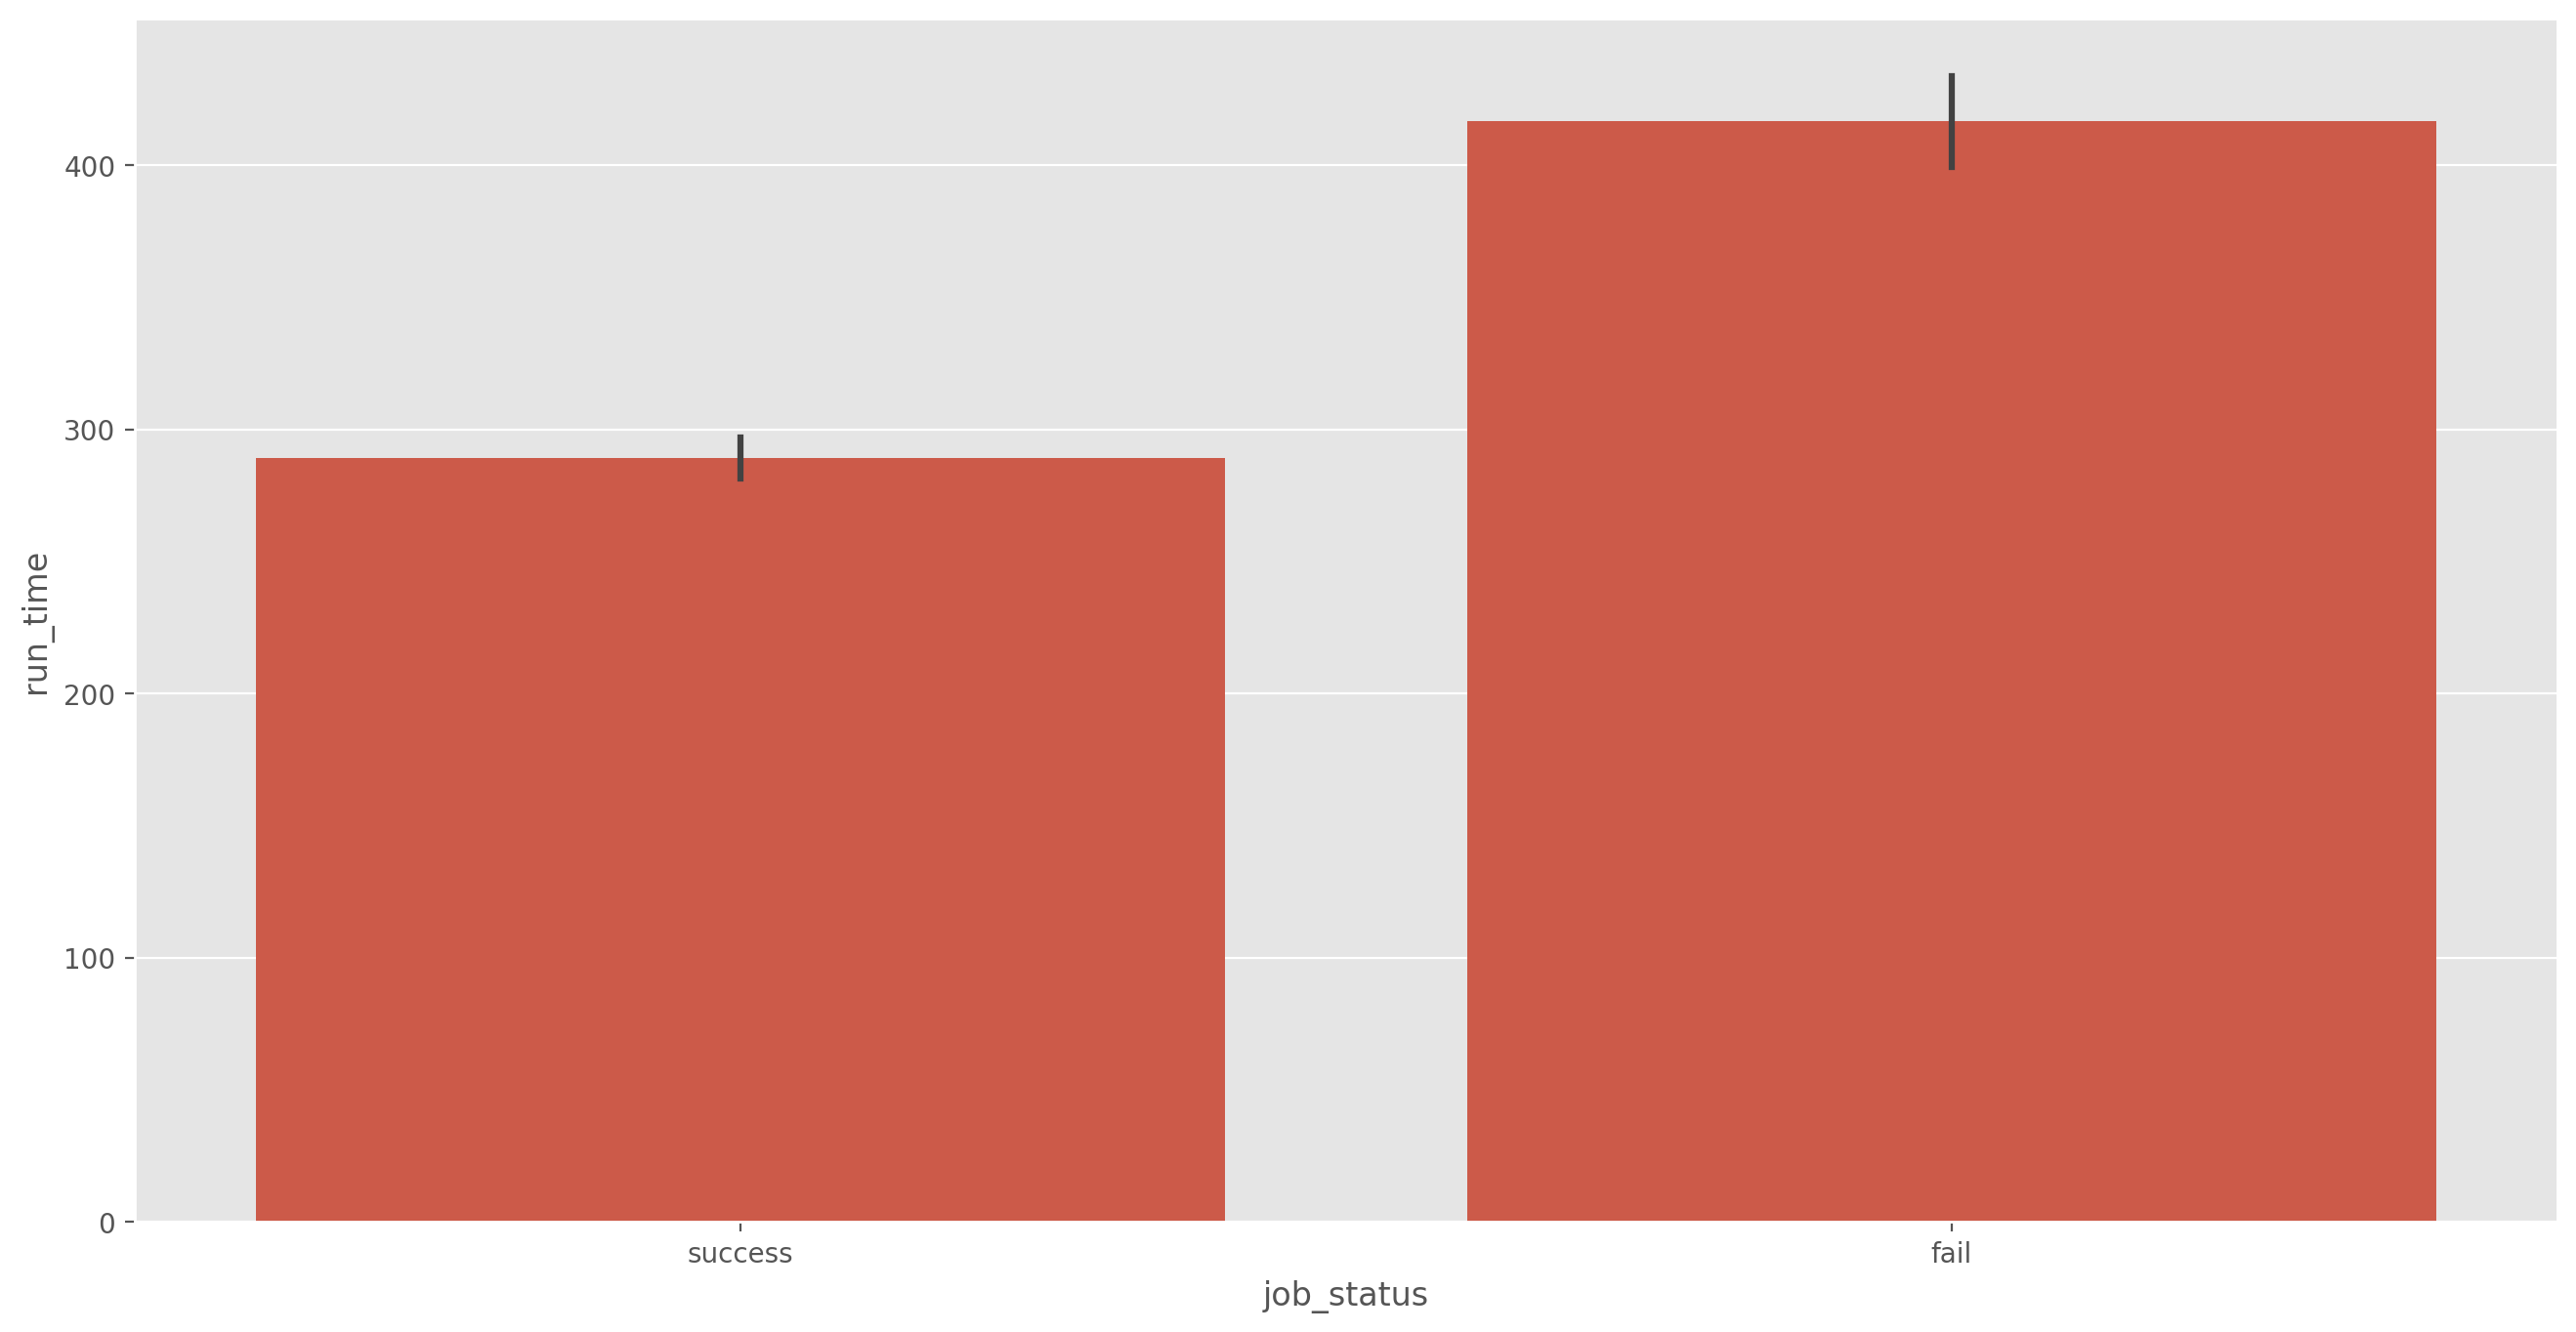

In [12]:
#Relationship between run time and job status
plt.figure(figsize=(16,8),dpi=200)
sns.barplot(y='run_time',x='job_status',data=df)

In [13]:
group = df.groupby('job_status')['run_time'].mean()
group

,run_time
job_status,
fail,416.677524
success,289.011813


Inference from above:
**higher the run time, chances of failure is high**

In [14]:
df.groupby('job_status')['records_processed'].mean()

,records_processed
job_status,
fail,71919.671010
success,75440.866509


<Axes: xlabel='job_status', ylabel='records_processed'>

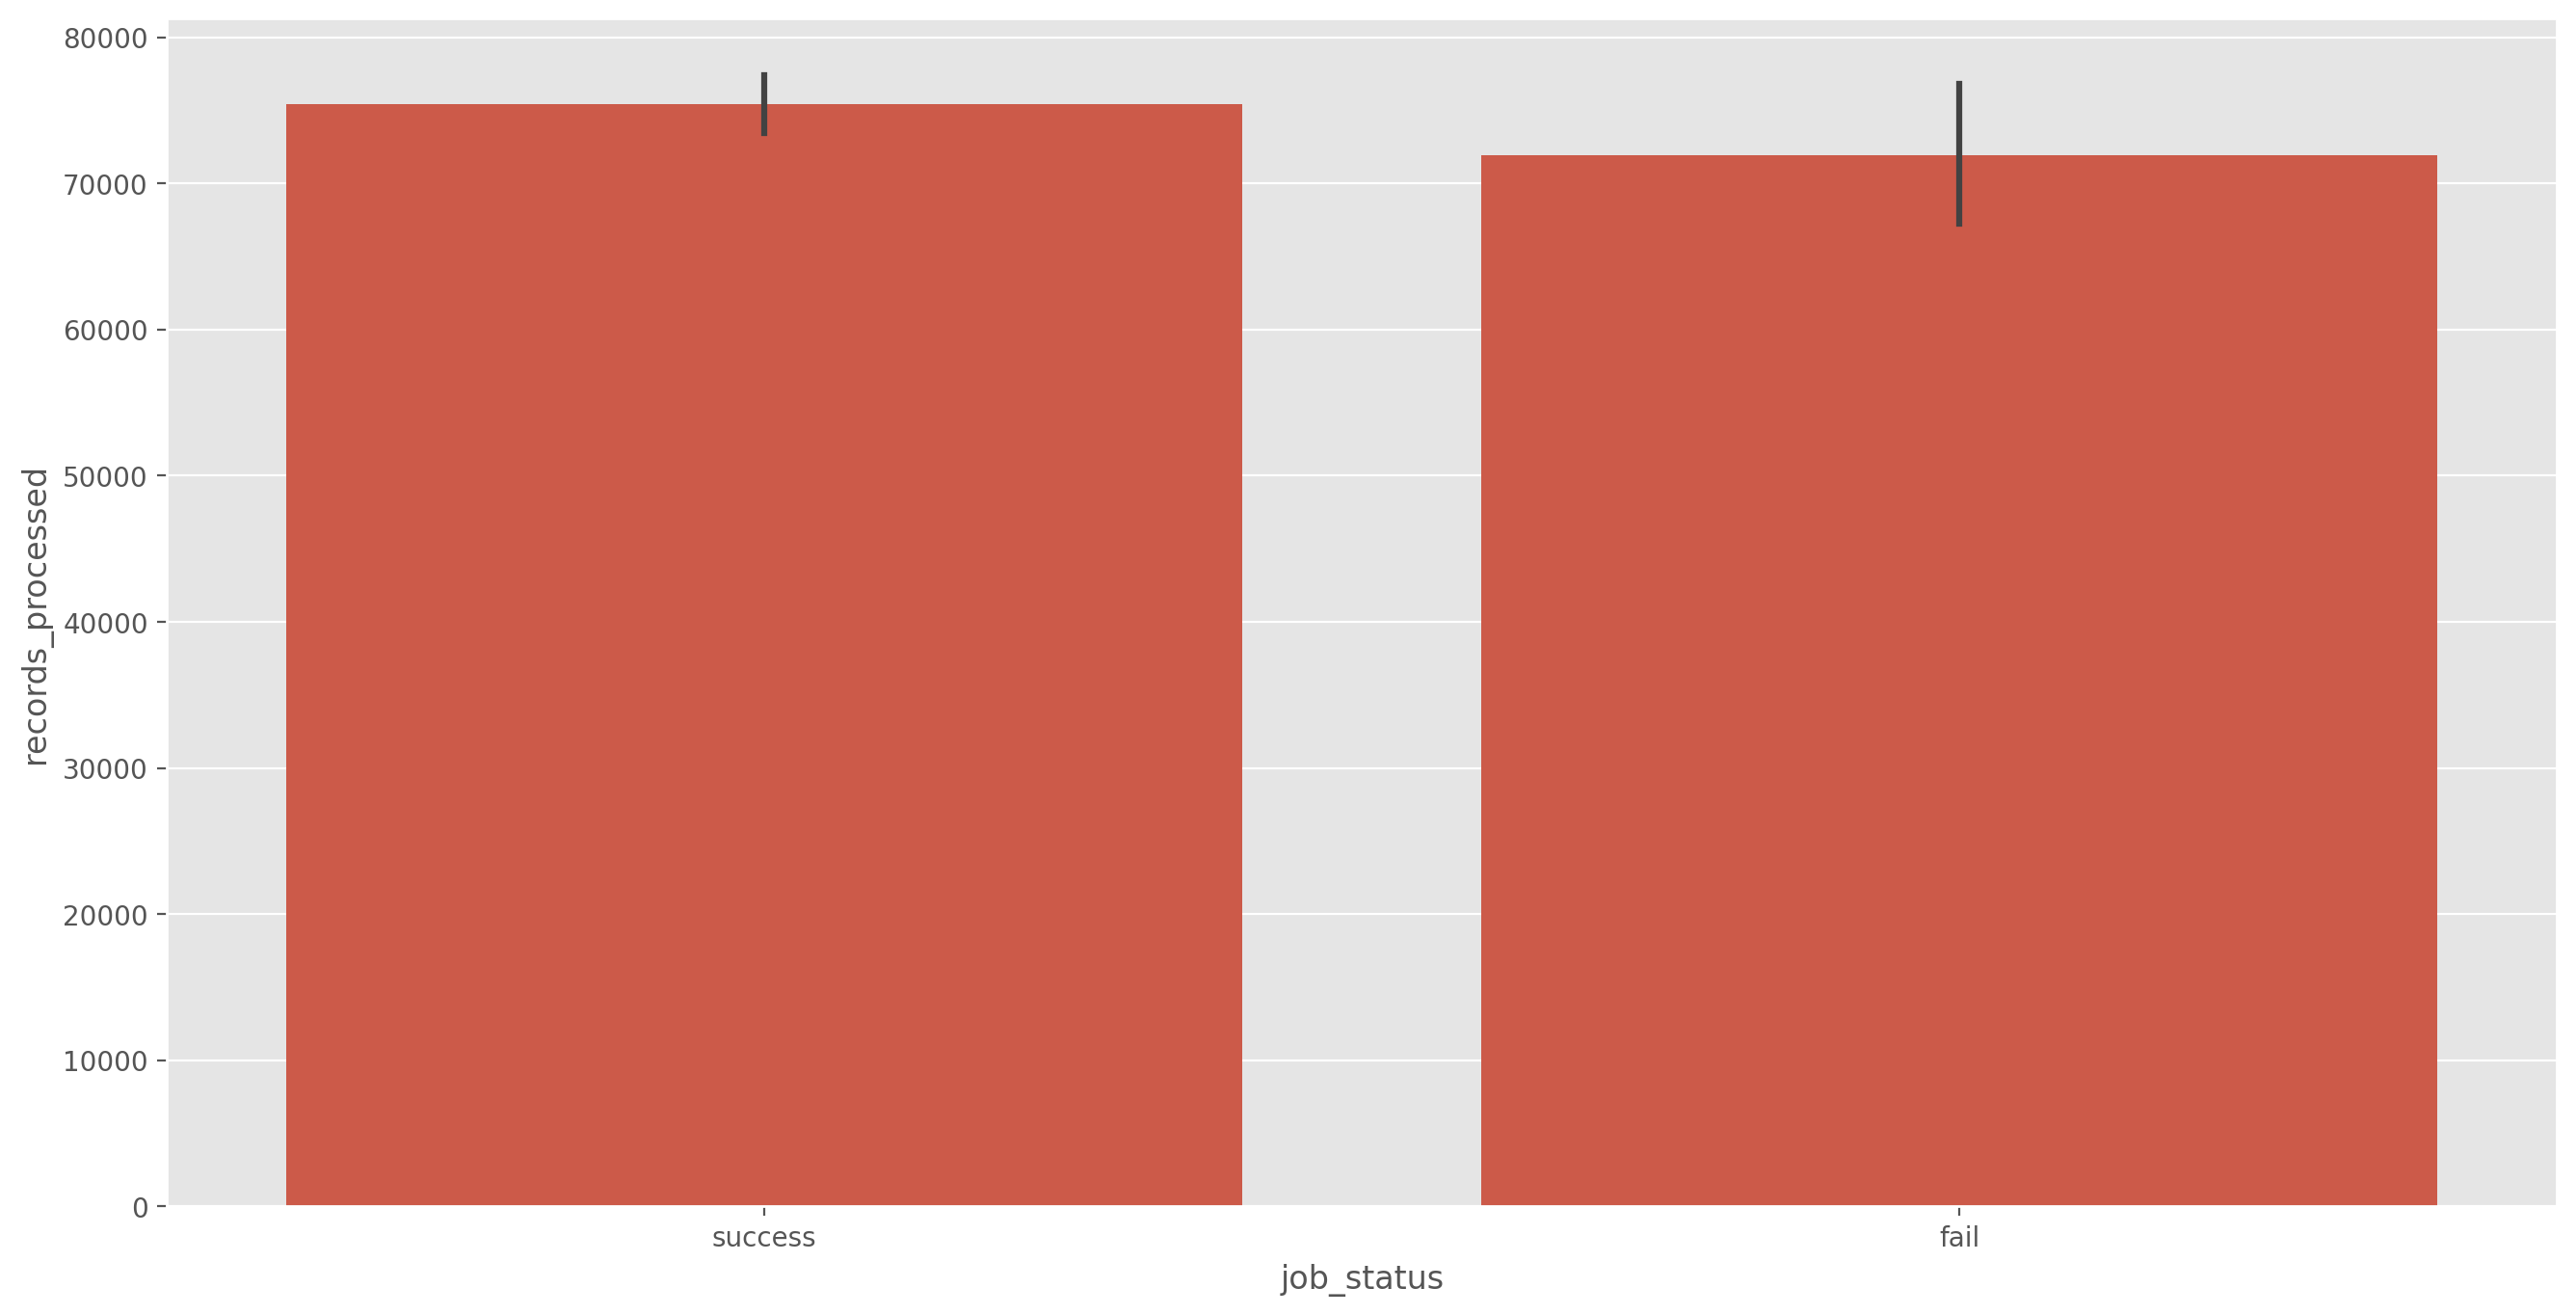

In [15]:
#Relationship between records processed and job status
plt.figure(figsize=(16,8),dpi=200)
sns.barplot(x='job_status',y='records_processed',data=df)

Inference from above:
**no relation between records processed and job status**

<Axes: xlabel='job_status', ylabel='cpu_time'>

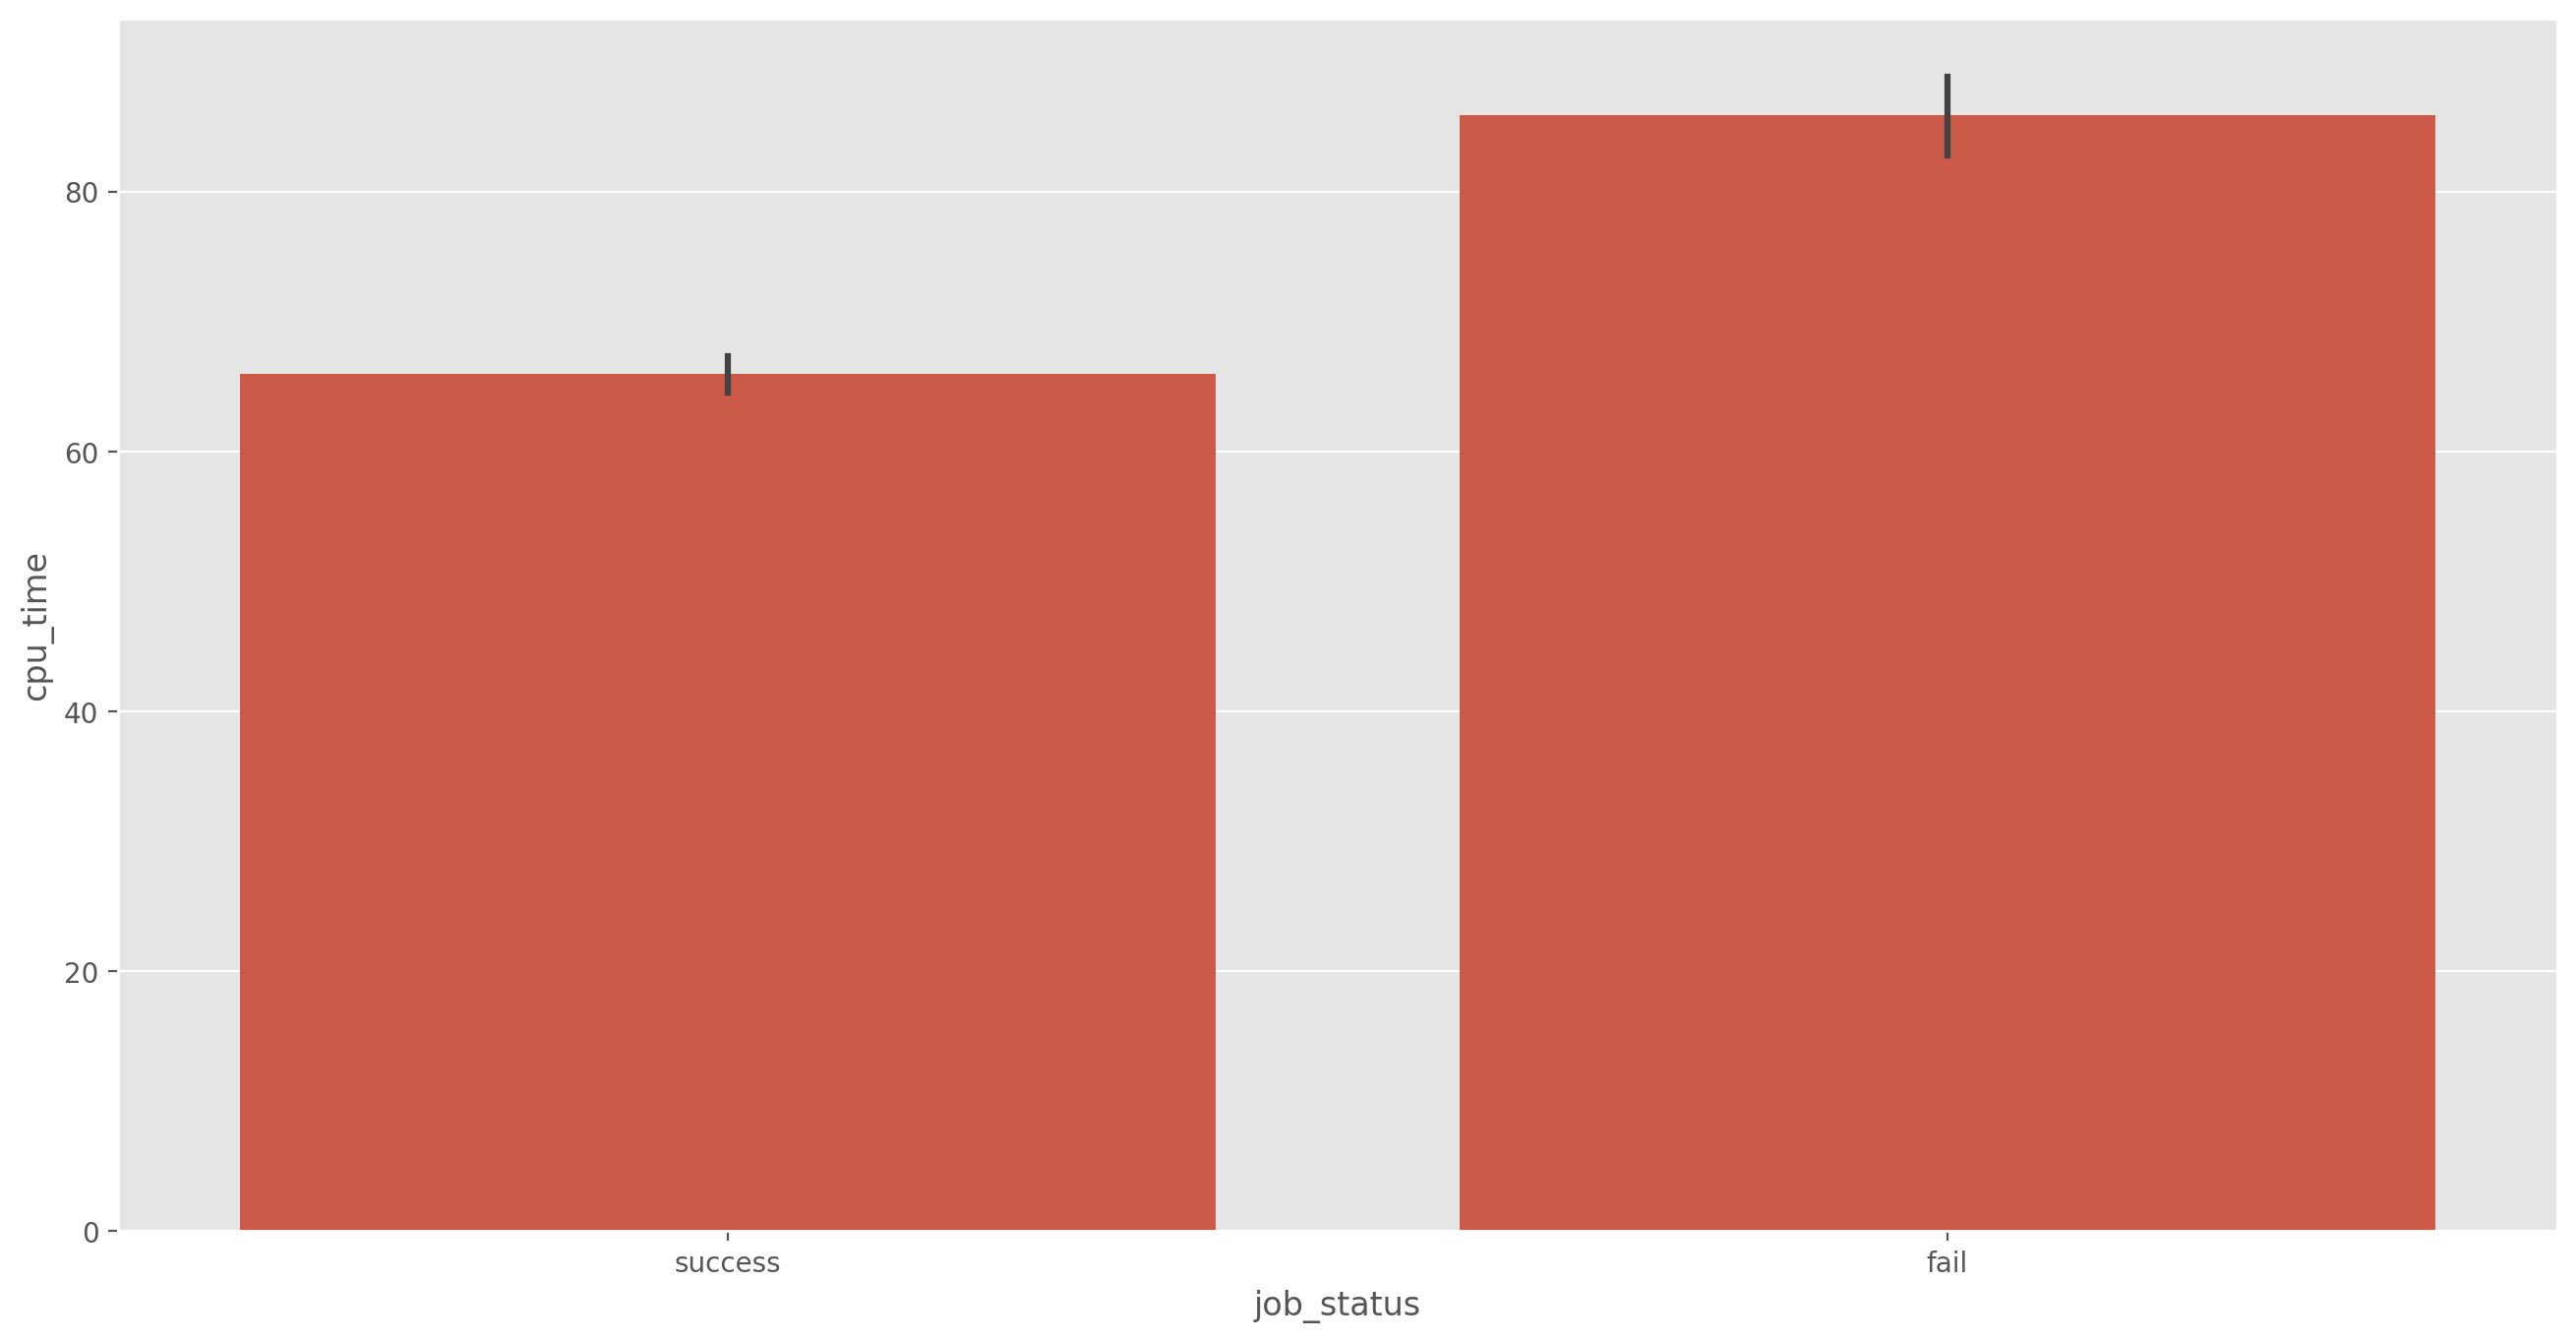

In [16]:
#Relationship between cpu time and job status
plt.figure(figsize=(16,8),dpi=200)
sns.barplot(y='cpu_time',x='job_status',data=df)

Inference from above:
**higher the records processed, chances of failure is high**

<Axes: xlabel='job_status', ylabel='memory_usage'>

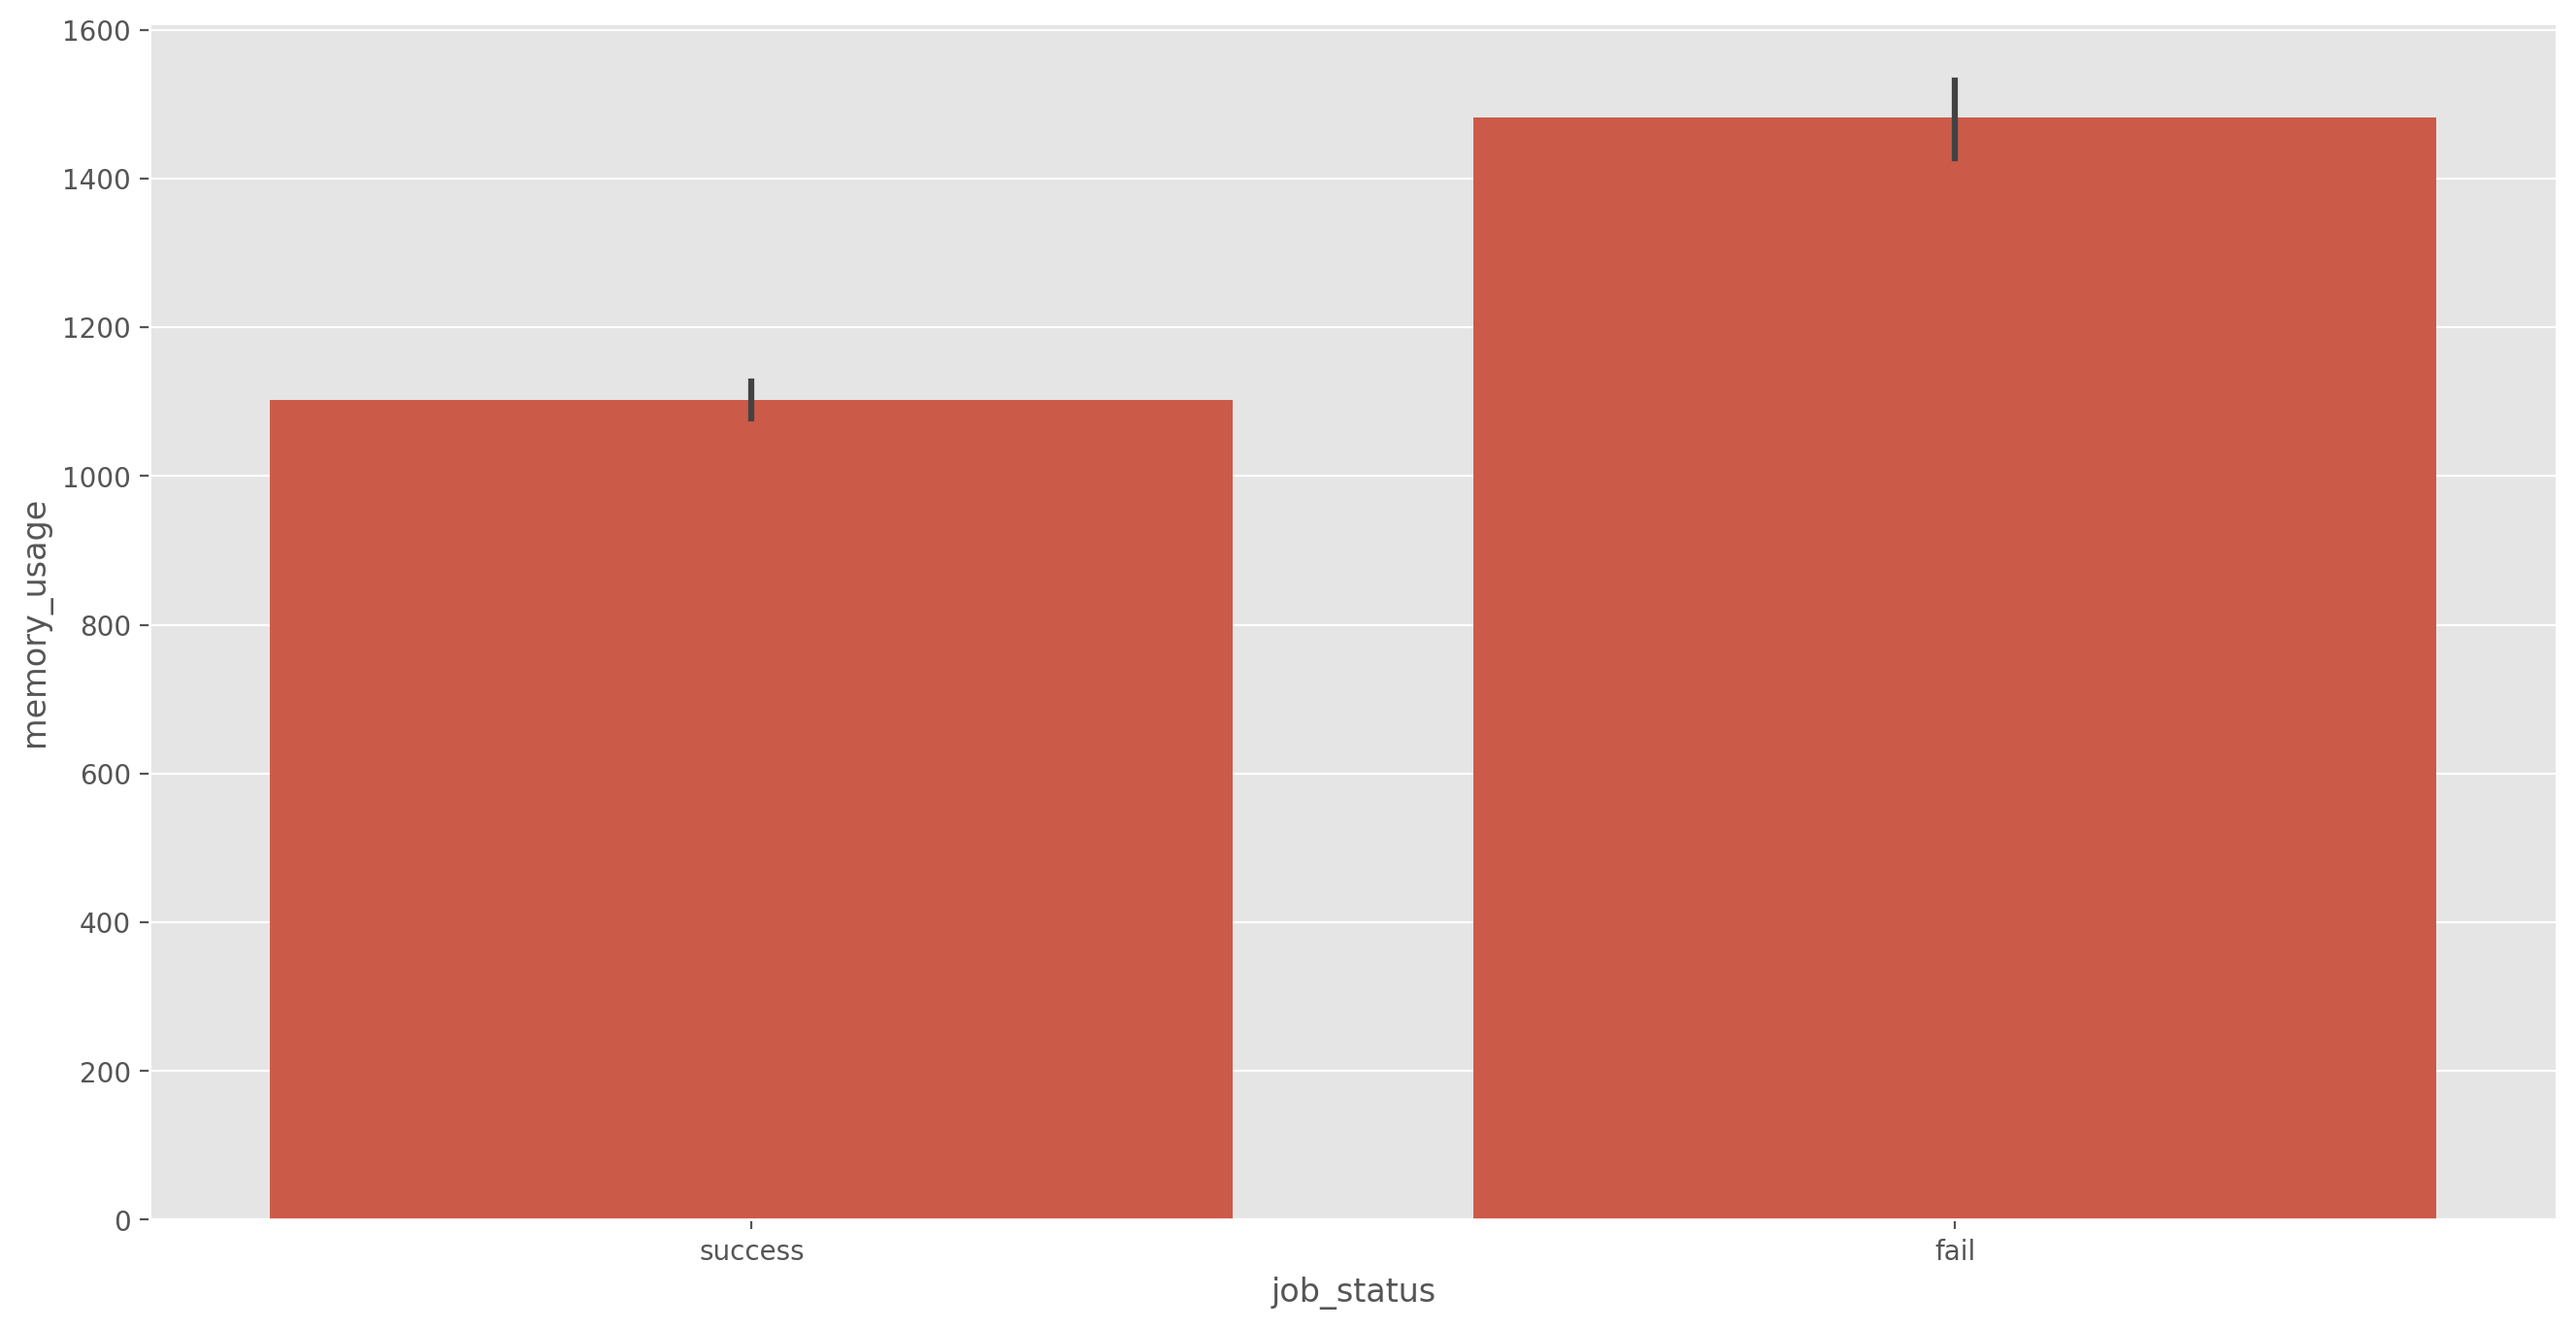

In [17]:
#Relationship between memory usage and job status
plt.figure(figsize=(16,8),dpi=200)
sns.barplot(x='job_status',y='memory_usage',data=df)

Inference from above:
**higher the memory usage, chances of failure is high**

In [18]:
#Relationship between day of run and job status
df.groupby('day_of_run')['job_status'].value_counts()

day_of_run  job_status
Friday      success       271
            fail           43
Monday      success       182
            fail          109
Saturday    success       261
            fail           31
Sunday      success       236
            fail           30
Thursday    success       280
            fail           34
Tuesday     success       226
            fail           30
Wednesday   success       237
            fail           30
Name: count, dtype: int64

<Axes: xlabel='day_of_run', ylabel='count'>

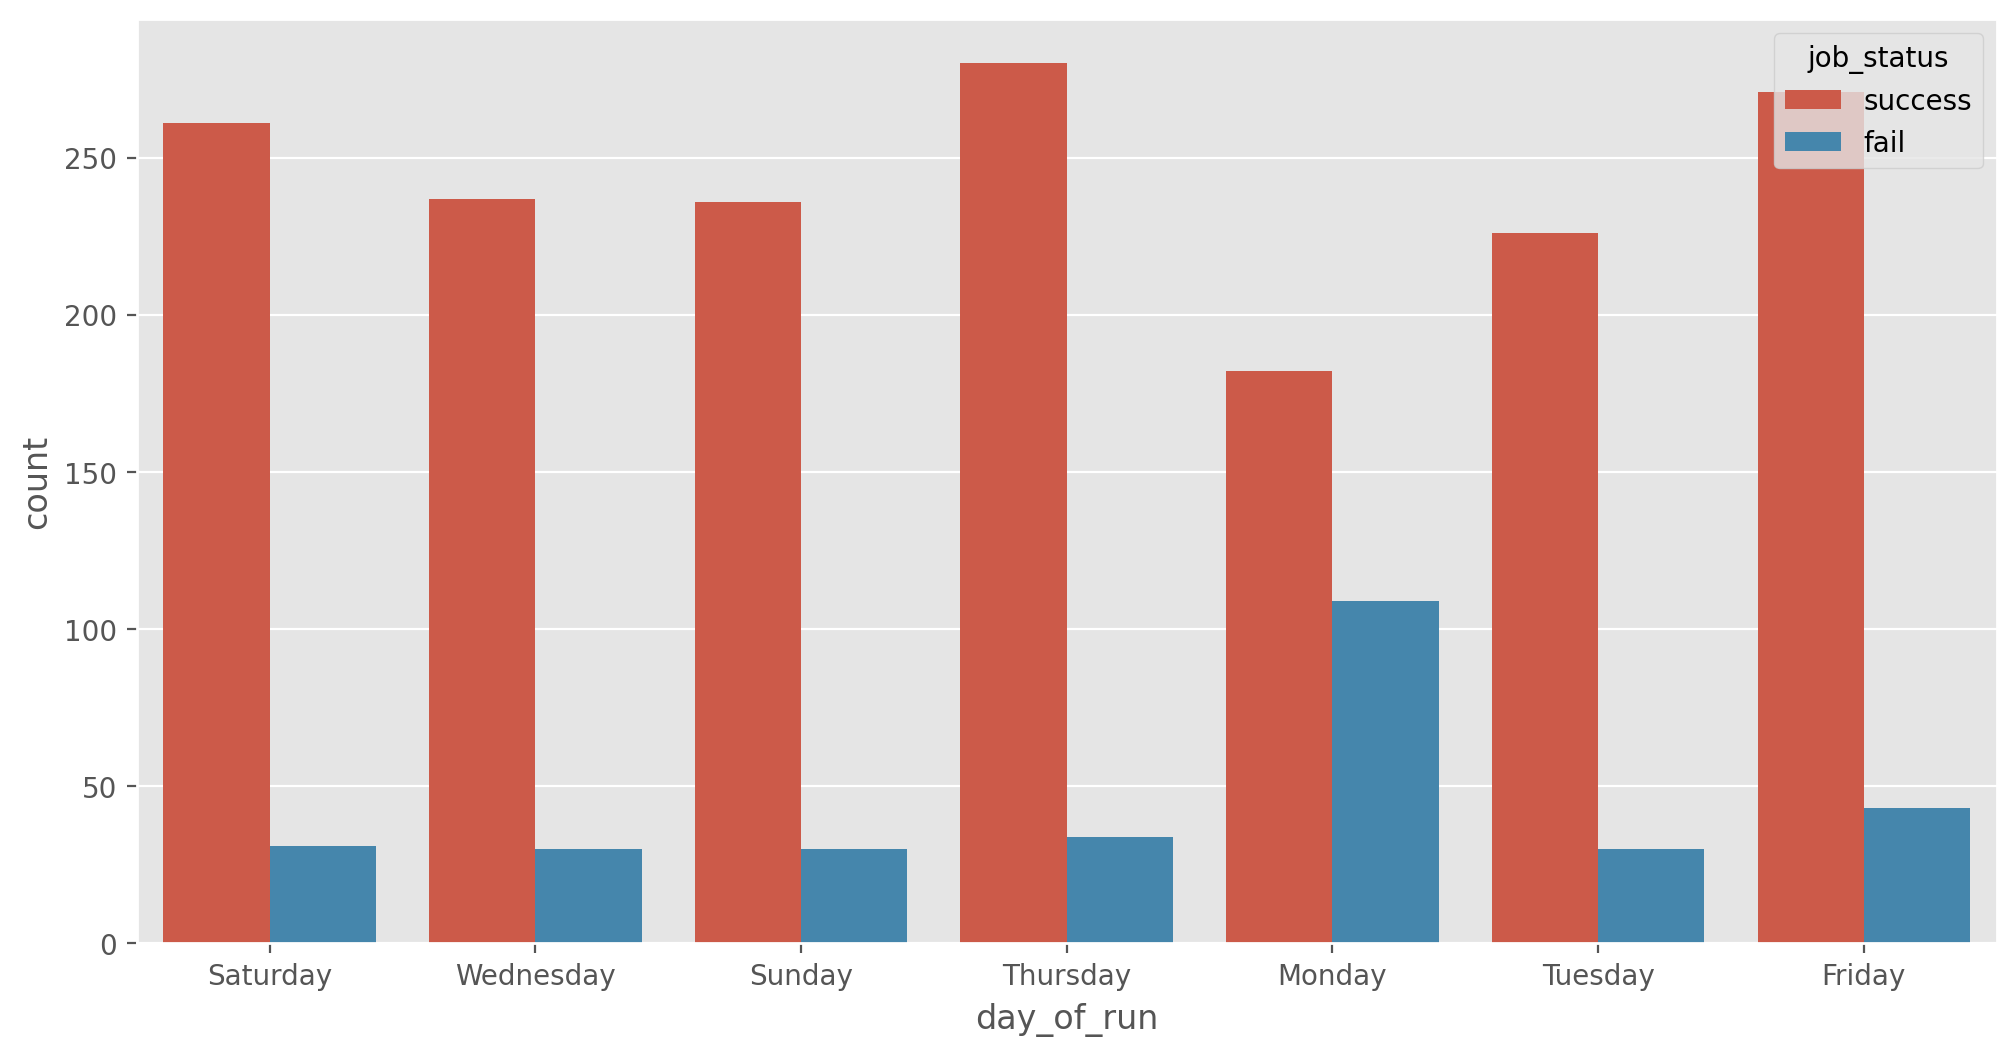

In [19]:
plt.figure(figsize=(12,6),dpi=200)
sns.countplot(x='day_of_run',hue='job_status',data=df)

Inference from above:
**on Mondays, chances of failure is high**

<Axes: xlabel='dependency_count', ylabel='count'>

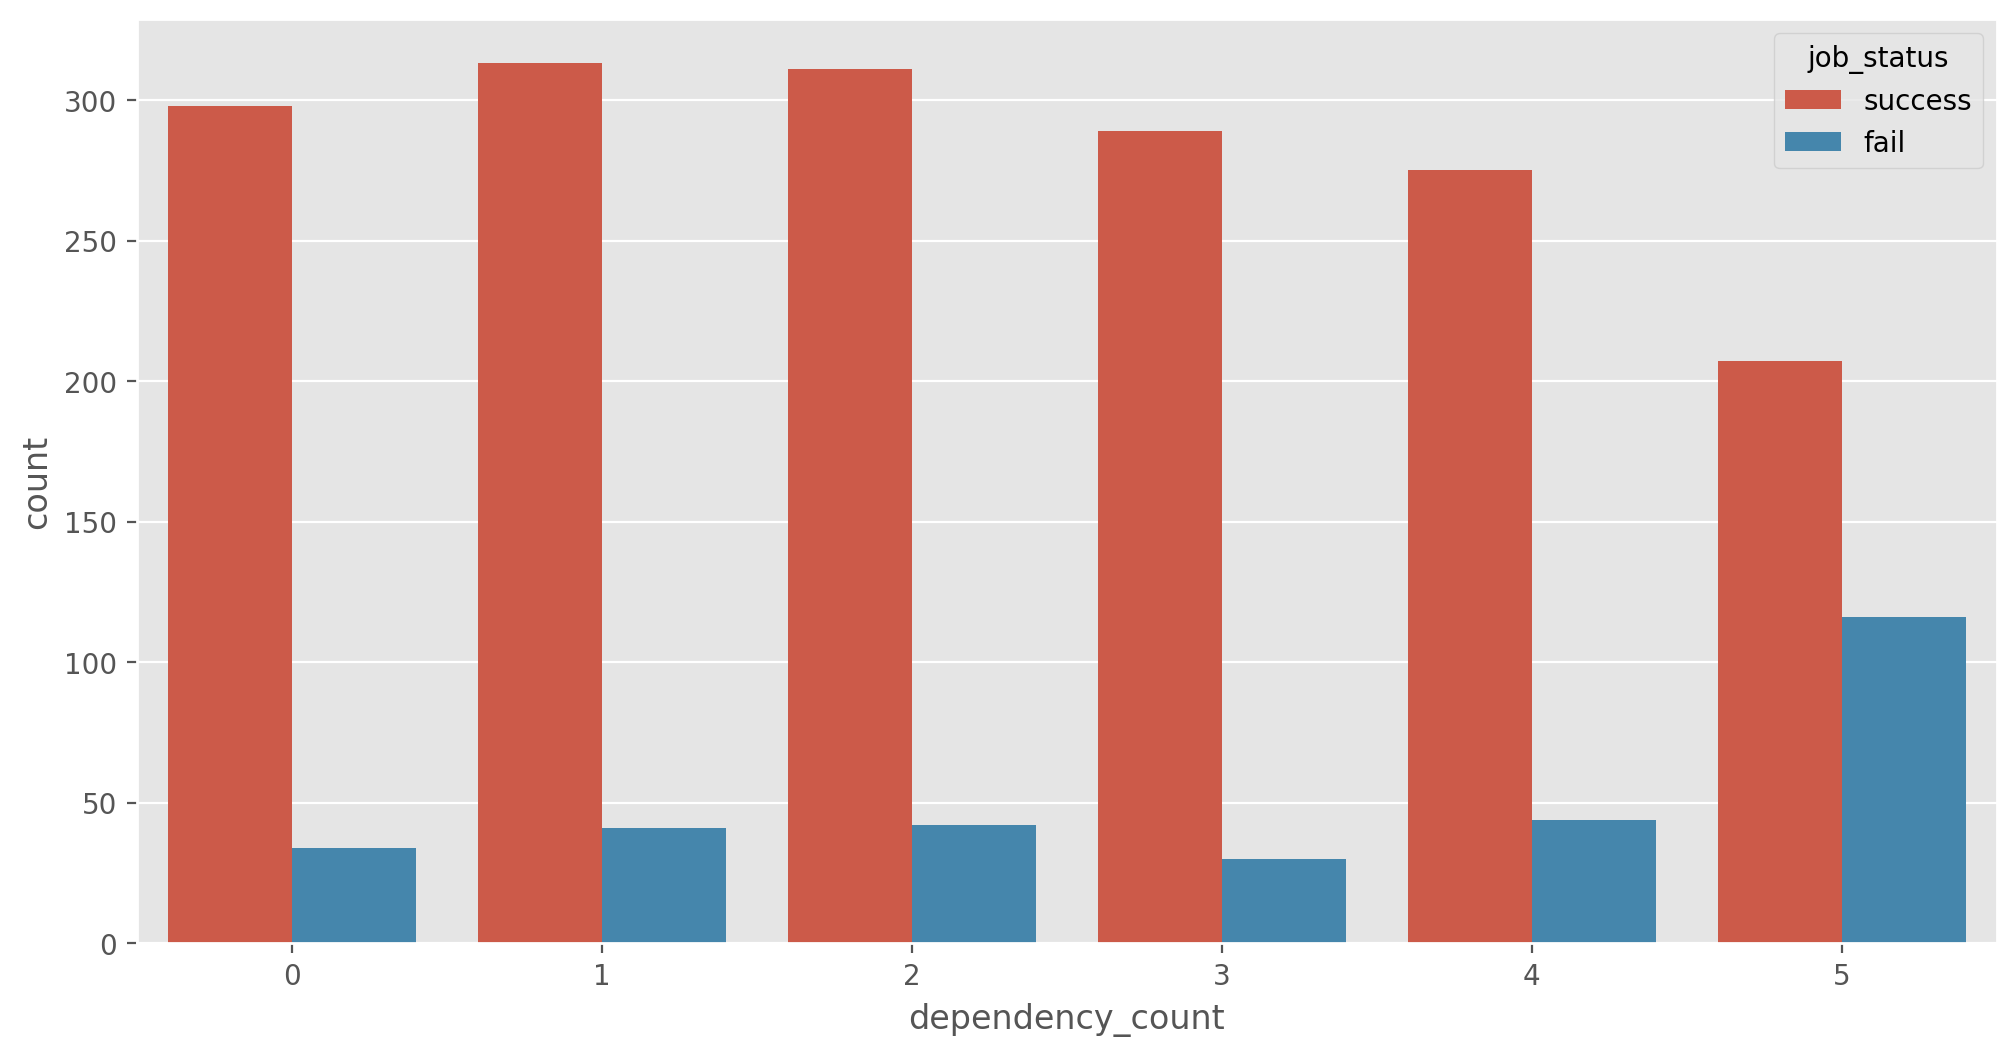

In [20]:
#Relationship between dependency count and job status
plt.figure(figsize=(12,6),dpi=200)
sns.countplot(x='dependency_count',hue='job_status',data=df)

In [21]:
df.groupby('job_status')['dependency_count'].value_counts()

job_status  dependency_count
fail        5                   116
            4                    44
            2                    42
            1                    41
            0                    34
            3                    30
success     1                   313
            2                   311
            0                   298
            3                   289
            4                   275
            5                   207
Name: count, dtype: int64

Inference from above:
**jobs with highest dependency fails the most**

<Axes: xlabel='previous_abend_count', ylabel='count'>

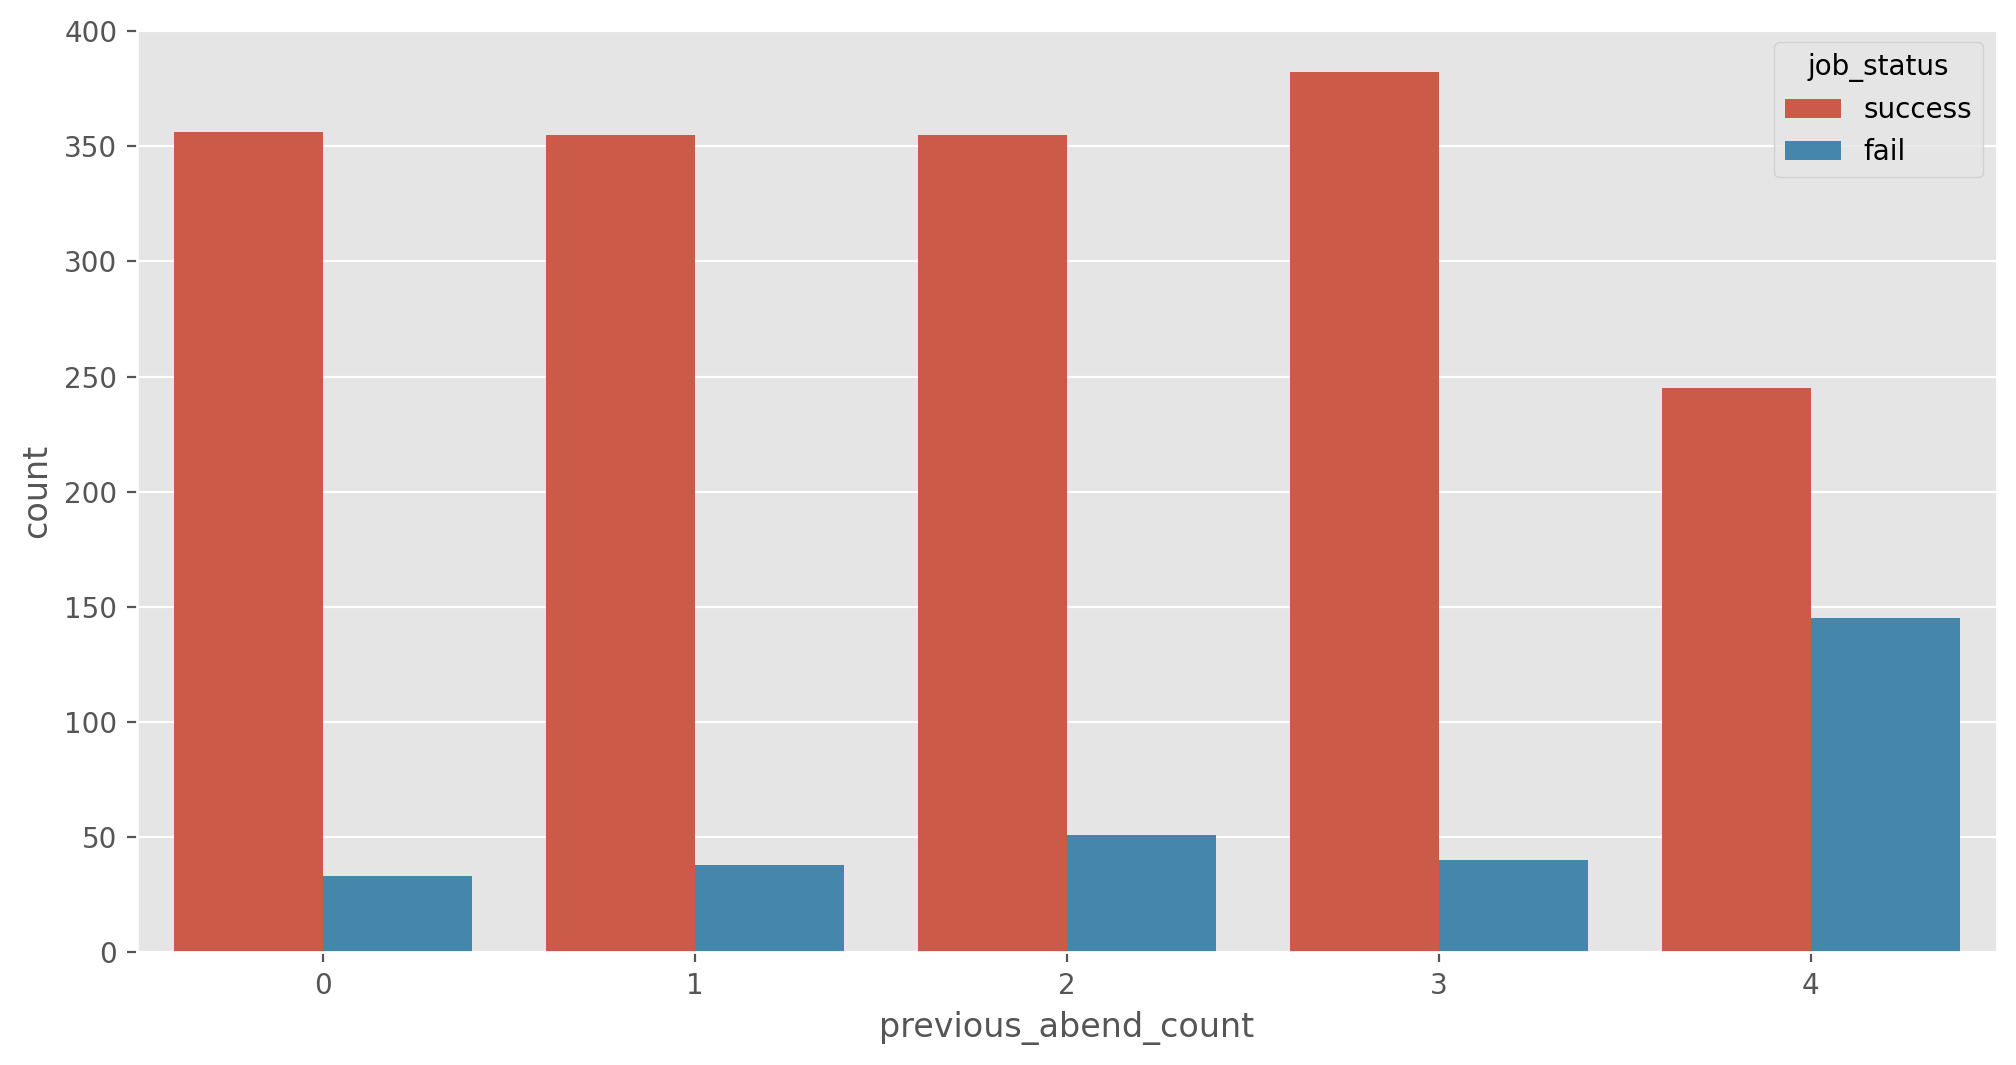

In [22]:
#Relationship between previous abend counts and job status
plt.figure(figsize=(12,6),dpi=200)
sns.countplot(x='previous_abend_count',hue='job_status',data=df)

Inference from above:
**jobs with highest previous abends fails the most**

---------
**Consolidated Inferences**

The below factors contribute to job failure:
*   More run time
*   More CPU time
* More memory usage
* Mondays
* High dependency count
* High abends in the past




--------
**Data Preprocessing**
----

In [23]:
from sklearn.preprocessing import OrdinalEncoder
encoder = OrdinalEncoder(categories=[['Sunday','Monday','Tuesday','Wednesday','Thursday','Friday','Saturday']])
df['day_of_run_encoded'] = encoder.fit_transform(df[['day_of_run']]).astype(int)

In [24]:
df.head(5)

,job_id,run_time,records_processed,cpu_time,memory_usage,day_of_run,dependency_count,previous_abend_count,job_status,day_of_run_encoded
0,JOB8415,254,18760,39,658,Saturday,4,2,success,6
1,JOB8262,537,38992,86,664,Saturday,5,1,success,6
2,JOB2323,393,5991,24,705,Wednesday,5,0,success,3
3,JOB1310,406,19201,43,1491,Sunday,0,3,success,0
4,JOB3542,111,77985,29,2015,Wednesday,5,3,success,3


In [25]:
from sklearn.preprocessing import OrdinalEncoder
encoder1 = OrdinalEncoder(categories=[['fail','success']])
df['job_status_encoded'] = encoder1.fit_transform(df[['job_status']]).astype(int)

In [26]:
df.head(5)

,job_id,run_time,records_processed,cpu_time,memory_usage,day_of_run,dependency_count,previous_abend_count,job_status,day_of_run_encoded,job_status_encoded
0,JOB8415,254,18760,39,658,Saturday,4,2,success,6,1
1,JOB8262,537,38992,86,664,Saturday,5,1,success,6,1
2,JOB2323,393,5991,24,705,Wednesday,5,0,success,3,1
3,JOB1310,406,19201,43,1491,Sunday,0,3,success,0,1
4,JOB3542,111,77985,29,2015,Wednesday,5,3,success,3,1


-------------
**Train-Test Split**
---------

In [27]:
X = df.drop(['job_id','day_of_run','job_status','job_status_encoded'],axis=1)
Y = df['job_status_encoded']

In [28]:
X.head(5)

,run_time,records_processed,cpu_time,memory_usage,dependency_count,previous_abend_count,day_of_run_encoded
0,254,18760,39,658,4,2,6
1,537,38992,86,664,5,1,6
2,393,5991,24,705,5,0,3
3,406,19201,43,1491,0,3,0
4,111,77985,29,2015,5,3,3


In [29]:
Y.head(5)

,job_status_encoded
0,1
1,1
2,1
3,1
4,1


In [30]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X,Y,test_size=0.2,random_state=2)

In [31]:
print('X Train Shape = ',x_train.shape)
print('Y Train Shape = ',y_train.shape)
print('X Test Shape = ',x_test.shape)
print('Y Test Shape = ',y_test.shape)

X Train Shape =  (1600, 7)
Y Train Shape =  (1600,)
X Test Shape =  (400, 7)
Y Test Shape =  (400,)


------------
**Model 1 - Logistic Regression with imbalanced dataset**
-----------

In [32]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(x_train,y_train)

LogisticRegression()

In [33]:
pred_train = model.predict(x_train)
pred_test = model.predict(x_test)

In [34]:
#Training Accuracy Calculation
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, log_loss
print("Results of Training Accuracy")
print("Confusion Matrix = ", confusion_matrix(y_train,pred_train))
print("Accuracy Score = ", accuracy_score(y_train,pred_train))
print("Precision Score = ", precision_score(y_train,pred_train))
print("Recall Score = ", recall_score(y_train,pred_train))
print("F1 Score = ", f1_score(y_train,pred_train))
print("Log Loss = ", log_loss(y_train,pred_train))

Results of Training Accuracy
Confusion Matrix =  [[  14  230]
 [  47 1309]]
Accuracy Score =  0.826875
Precision Score =  0.8505523066926576
Recall Score =  0.9653392330383481
F1 Score =  0.9043177892918826
Log Loss =  6.240057492990907


In [35]:
#Testing Accuracy Calculation
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, log_loss
print("Results of Testing Accuracy")
print("Confusion Matrix = ", confusion_matrix(y_test,pred_test))
print("Accuracy Score = ", accuracy_score(y_test,pred_test))
print("Precision Score = ", precision_score(y_test,pred_test))
print("Recall Score = ", recall_score(y_test,pred_test))
print("F1 Score = ", f1_score(y_test,pred_test))
print("Log Loss = ", log_loss(y_test,pred_test))

Results of Testing Accuracy
Confusion Matrix =  [[  9  54]
 [  7 330]]
Accuracy Score =  0.8475
Precision Score =  0.859375
Recall Score =  0.9792284866468842
F1 Score =  0.9153952843273232
Log Loss =  5.496657141840366


In [36]:
from sklearn.metrics import classification_report
print(classification_report(y_test, pred_test))

              precision    recall  f1-score   support

           0       0.56      0.14      0.23        63
           1       0.86      0.98      0.92       337

    accuracy                           0.85       400
   macro avg       0.71      0.56      0.57       400
weighted avg       0.81      0.85      0.81       400



From the scores, it is evident that the dataset is imbalanced. So the next try is to balance the dataset and use Logistic Regression

**Model 2 - Logistic Regression with balanced data**
---

In [37]:
from imblearn.under_sampling import NearMiss
nm_sampler = NearMiss()
x_sample, y_sample = nm_sampler.fit_resample(x_train,y_train)

In [38]:
from sklearn.linear_model import LogisticRegression
model1 = LogisticRegression()
model1.fit(x_sample,y_sample)

LogisticRegression()

In [39]:
pred_train_bal = model1.predict(x_sample)
pred_test_bal = model1.predict(x_test)

In [40]:
#Training Accuracy Calculation
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, log_loss
print("Results of Training Accuracy")
print("Confusion Matrix = ", confusion_matrix(y_sample,pred_train_bal))
print("Accuracy Score = ", accuracy_score(y_sample,pred_train_bal))
print("Precision Score = ", precision_score(y_sample,pred_train_bal))
print("Recall Score = ", recall_score(y_sample,pred_train_bal))
print("F1 Score = ", f1_score(y_sample,pred_train_bal))
print("Log Loss = ", log_loss(y_sample,pred_train_bal))

Results of Training Accuracy
Confusion Matrix =  [[186  58]
 [ 90 154]]
Accuracy Score =  0.6967213114754098
Precision Score =  0.7264150943396226
Recall Score =  0.6311475409836066
F1 Score =  0.6754385964912281
Log Loss =  10.931271929486348


In [41]:
#Testing Accuracy Calculation
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, log_loss
print("Results of Testing Accuracy")
print("Confusion Matrix = ", confusion_matrix(y_test,pred_test_bal))
print("Accuracy Score = ", accuracy_score(y_test,pred_test_bal))
print("Precision Score = ", precision_score(y_test,pred_test_bal))
print("Recall Score = ", recall_score(y_test,pred_test_bal))
print("F1 Score = ", f1_score(y_test,pred_test_bal))
print("Log Loss = ", log_loss(y_test,pred_test_bal))

Results of Testing Accuracy
Confusion Matrix =  [[ 50  13]
 [148 189]]
Accuracy Score =  0.5975
Precision Score =  0.9356435643564357
Recall Score =  0.5608308605341247
F1 Score =  0.7012987012987013
Log Loss =  14.507570489119653


In [42]:
from sklearn.metrics import classification_report
print(classification_report(y_test, pred_test_bal))

              precision    recall  f1-score   support

           0       0.25      0.79      0.38        63
           1       0.94      0.56      0.70       337

    accuracy                           0.60       400
   macro avg       0.59      0.68      0.54       400
weighted avg       0.83      0.60      0.65       400



**Model 3 - Logistic Regression using class weight**
-----

In [43]:
from sklearn.linear_model import LogisticRegression
model2 = LogisticRegression(class_weight='balanced',max_iter=1000)
model2.fit(x_train,y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [44]:
pred_train_class = model2.predict(x_train)
pred_test_class = model2.predict(x_test)

In [45]:
#Training Accuracy Calculation
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, log_loss
print("Results of Training Accuracy")
print("Confusion Matrix = ", confusion_matrix(y_train,pred_train_class))
print("Accuracy Score = ", accuracy_score(y_train,pred_train_class))
print("Precision Score = ", precision_score(y_train,pred_train_class))
print("Recall Score = ", recall_score(y_train,pred_train_class))
print("F1 Score = ", f1_score(y_train,pred_train_class))
print("Log Loss = ", log_loss(y_train,pred_train_class))

Results of Training Accuracy
Confusion Matrix =  [[ 205   39]
 [ 240 1116]]
Accuracy Score =  0.825625
Precision Score =  0.9662337662337662
Recall Score =  0.8230088495575221
F1 Score =  0.8888888888888888
Log Loss =  6.285112059727303


In [46]:
#Testing Accuracy Calculation
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, log_loss
print("Results of Testing Accuracy")
print("Confusion Matrix = ", confusion_matrix(y_test,pred_test_class))
print("Accuracy Score = ", accuracy_score(y_test,pred_test_class))
print("Precision Score = ", precision_score(y_test,pred_test_class))
print("Recall Score = ", recall_score(y_test,pred_test_class))
print("F1 Score = ", f1_score(y_test,pred_test_class))
print("Log Loss = ", log_loss(y_test,pred_test_class))

Results of Testing Accuracy
Confusion Matrix =  [[ 55   8]
 [ 58 279]]
Accuracy Score =  0.835
Precision Score =  0.9721254355400697
Recall Score =  0.827893175074184
F1 Score =  0.8942307692307693
Log Loss =  5.94720280920433


In [47]:
from sklearn.metrics import classification_report
print(classification_report(y_test, pred_test_class))

              precision    recall  f1-score   support

           0       0.49      0.87      0.62        63
           1       0.97      0.83      0.89       337

    accuracy                           0.83       400
   macro avg       0.73      0.85      0.76       400
weighted avg       0.90      0.83      0.85       400



**Model 4 - Random Forest**
-------

In [55]:
from sklearn.ensemble import RandomForestClassifier
model3 = RandomForestClassifier(n_estimators=200,max_depth=10,max_features=5,class_weight='balanced')
model3.fit(x_train,y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, max_features=5,
                       n_estimators=200)

In [57]:
pred_train_rf = model3.predict(x_train)
pred_test_rf = model3.predict(x_test)

In [58]:
#Training Accuracy Calculation
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, log_loss
print("Results of Training Accuracy")
print("Confusion Matrix = ", confusion_matrix(y_train,pred_train_rf))
print("Accuracy Score = ", accuracy_score(y_train,pred_train_rf))
print("Precision Score = ", precision_score(y_train,pred_train_rf))
print("Recall Score = ", recall_score(y_train,pred_train_rf))
print("F1 Score = ", f1_score(y_train,pred_train_rf))
print("Log Loss = ", log_loss(y_train,pred_train_rf))

Results of Training Accuracy
Confusion Matrix =  [[ 244    0]
 [   0 1356]]
Accuracy Score =  1.0
Precision Score =  1.0
Recall Score =  1.0
F1 Score =  1.0
Log Loss =  2.2204460492503136e-16


In [59]:
#Testing Accuracy Calculation
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, log_loss
print("Results of Testing Accuracy")
print("Confusion Matrix = ", confusion_matrix(y_test,pred_test_rf))
print("Accuracy Score = ", accuracy_score(y_test,pred_test_rf))
print("Precision Score = ", precision_score(y_test,pred_test_rf))
print("Recall Score = ", recall_score(y_test,pred_test_rf))
print("F1 Score = ", f1_score(y_test,pred_test_rf))
print("Log Loss = ", log_loss(y_test,pred_test_rf))

Results of Testing Accuracy
Confusion Matrix =  [[ 48  15]
 [  1 336]]
Accuracy Score =  0.96
Precision Score =  0.9572649572649573
Recall Score =  0.9970326409495549
F1 Score =  0.9767441860465116
Log Loss =  1.4417461355646861


In [60]:
from sklearn.metrics import classification_report
print(classification_report(y_test, pred_test_rf))

              precision    recall  f1-score   support

           0       0.98      0.76      0.86        63
           1       0.96      1.00      0.98       337

    accuracy                           0.96       400
   macro avg       0.97      0.88      0.92       400
weighted avg       0.96      0.96      0.96       400



In [61]:
feature_importance = pd.Series(
    model3.feature_importances_,
    index=x_train.columns
).sort_values(ascending=False)

print(feature_importance)

memory_usage            0.212660
run_time                0.208380
previous_abend_count    0.162142
cpu_time                0.152689
dependency_count        0.119566
day_of_run_encoded      0.116464
records_processed       0.028099
dtype: float64


In [62]:
import pickle
pickle.dump(model3, open("batch_failure_model.pkl", "wb"))

In [64]:
from google.colab import files
files.download("batch_failure_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>